In [31]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# 1. Ambil data hasil pre-processing Anda
folder_sumber = r"C:\Users\Balqoz\skripsiku\Hasil ExG"
files = glob.glob(os.path.join(folder_sumber, "Hasil_ExG_*.xlsx"))
df_all = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)

In [32]:
# 2. Feature Engineering: Tambahkan Fitur IR dan Rasio IR terhadap RGB
df_all['IR_to_R'] = df_all['IR_Intensity (%)'] / (df_all['R'] + 1)
df_all['IR_to_G'] = df_all['IR_Intensity (%)'] / (df_all['G'] + 1)
df_all['IR_to_B'] = df_all['IR_Intensity (%)'] / (df_all['B'] + 1)

# Definisikan Fitur X (Menggunakan .values agar berupa NumPy array yang aman untuk LOOCV)
X = df_all[["r", "g", "b", "Excess_Green", "IR_Intensity (%)", "IR_to_R", "IR_to_G", "IR_to_B"]].values

# Menyiapkan 3 Target Aktual Terpisah Menggunakan Rasio Konstanta Arnon Secara Ilmiah
y_total_real = df_all["Chl_Total"].values
y_a_real = y_total_real * 0.7205
y_b_real = y_total_real * 0.2795

In [33]:
# 3. Evaluasi Menggunakan LOOCV dengan Melatih 3 Model Regresi Terpisah (XGBoost Berbasis Stochastic)
loo = LeaveOneOut()

# List penampung hasil prediksi untuk masing-masing model independen
y_pred_a_list = []
y_pred_b_list = []
y_pred_total_list = []

# Proses LOOCV (Tiap sampel akan diuji secara bergantian)
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]

    # --- MODEL 1: Khusus Melatih Prediksi Klorofil a ---
    model_xgb_a = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
    model_xgb_a.fit(X_train, y_a_real[train_index])
    y_pred_a_list.append(model_xgb_a.predict(X_test)[0])
    
    # --- MODEL 2: Khusus Melatih Prediksi Klorofil b ---
    model_xgb_b = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
    model_xgb_b.fit(X_train, y_b_real[train_index])
    y_pred_b_list.append(model_xgb_b.predict(X_test)[0])
    
    # --- MODEL 3: Khusus Melatih Prediksi Total Klorofil ---
    model_xgb_total = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
    model_xgb_total.fit(X_train, y_total_real[train_index])
    y_pred_total_list.append(model_xgb_total.predict(X_test)[0])

# Konversi seluruh hasil list prediksi menjadi numpy array
y_pred_a_all = np.array(y_pred_a_list)
y_pred_b_all = np.array(y_pred_b_list)
y_pred_total_all = np.array(y_pred_total_list)

In [34]:
# 4. Hitung Metrik Evaluasi Komprehensif (Tampilan output Bahasa Inggris, judul model XGBoost)
def hitung_metrik(y_true, y_pred, nama_komponen):
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    
    print(f"-------- {nama_komponen} Evaluation (XGBoost + IR) --------")
    print(f"R² Score : {r2:.4f}")
    print(f"MAPE     : {mape:.2f}%")
    print(f"MAE      : {mae:.4f}")
    print(f"MSE      : {mse:.4f}\n")

print("=====================================================")
print("      EVALUATION RESULTS FOR THE SEPARATED XGBOOST MODEL     ")
print("=====================================================")
hitung_metrik(y_a_real, y_pred_a_all, "Chlorophyll a")
hitung_metrik(y_b_real, y_pred_b_all, "Chlorophyll b")
hitung_metrik(y_total_real, y_pred_total_all, "Total Chlorophyll")

      EVALUATION RESULTS FOR THE SEPARATED XGBOOST MODEL     
-------- Chlorophyll a Evaluation (XGBoost + IR) --------
R² Score : 0.7292
MAPE     : 3.54%
MAE      : 0.5759
MSE      : 0.8804

-------- Chlorophyll b Evaluation (XGBoost + IR) --------
R² Score : 0.7292
MAPE     : 3.54%
MAE      : 0.2234
MSE      : 0.1325

-------- Total Chlorophyll Evaluation (XGBoost + IR) --------
R² Score : 0.7292
MAPE     : 3.54%
MAE      : 0.7993
MSE      : 1.6960



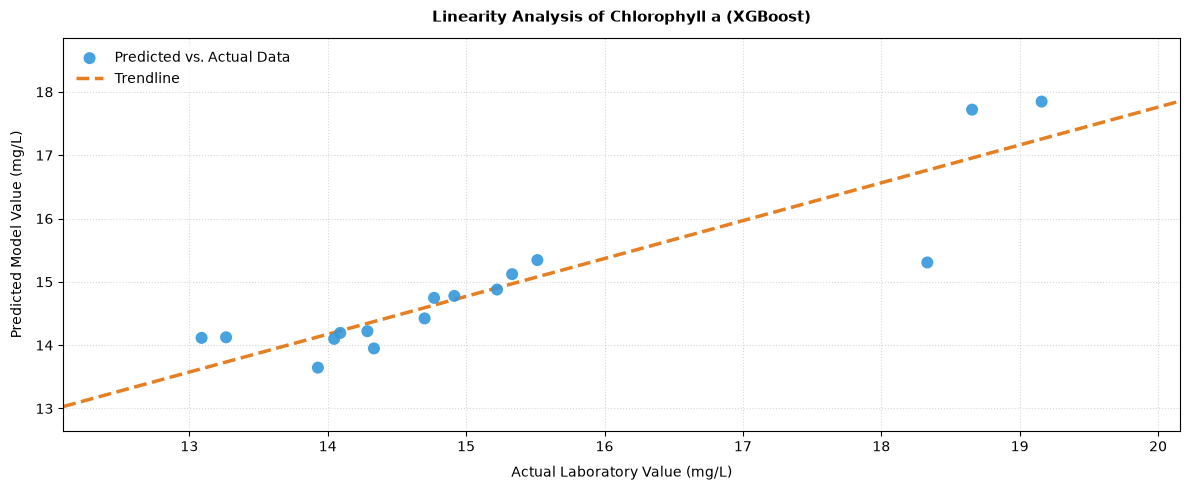

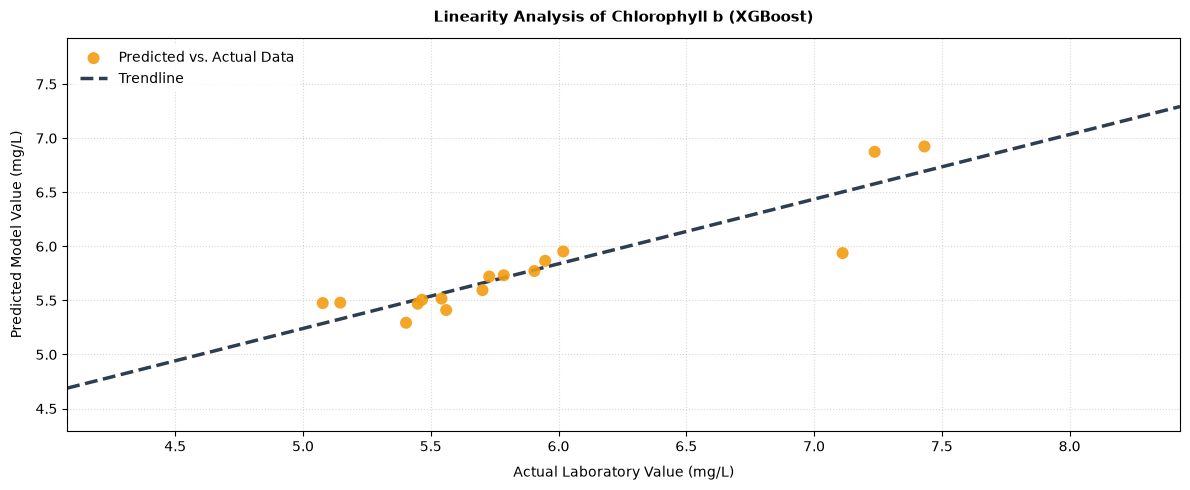

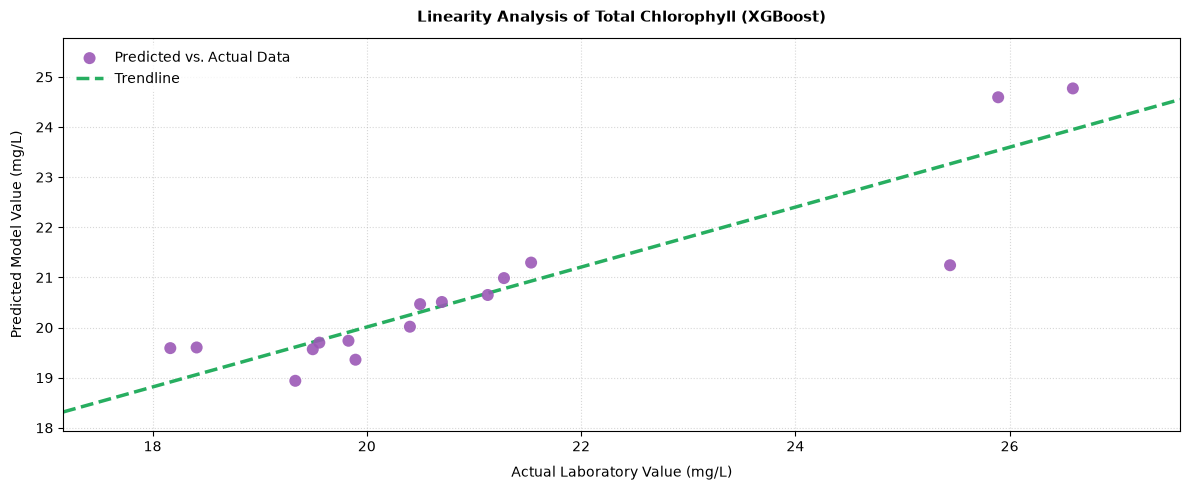

In [35]:
# ==========================================
# 1. SCATTER PLOT LINEARITAS KLOROFIL A (BLUE-TEAL & ORANGE)
# ==========================================
plt.figure(figsize=(12, 5)) 

plt.scatter(y_a_real, y_pred_a_all, color='#3498DB', s=75, alpha=0.9, edgecolors='none', zorder=3, 
            label='Predicted vs. Actual Data')

slope_a, intercept_a = np.polyfit(y_a_real, y_pred_a_all, 1)
x_trend_a = np.linspace(np.min(y_a_real) - 1, np.max(y_a_real) + 1, 100)
y_trend_a = slope_a * x_trend_a + intercept_a

plt.plot(x_trend_a, y_trend_a, color='#E67E22', linestyle='--', linewidth=2.5, zorder=2, 
         label='Trendline')

plt.title('Linearity Analysis of Chlorophyll a (XGBoost)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Actual Laboratory Value (mg/L)', fontsize=10, labelpad=8)
plt.ylabel('Predicted Model Value (mg/L)', fontsize=10, labelpad=8)

plt.xlim(np.min(y_a_real) - 1, np.max(y_a_real) + 1)
plt.ylim(np.min(y_pred_a_all) - 1, np.max(y_pred_a_all) + 1)

plt.grid(True, linestyle=':', alpha=0.5, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()


# ==========================================
# 2. SCATTER PLOT LINEARITAS KLOROFIL B (ORANGE PASTEL & DEEP BLUE)
# ==========================================
plt.figure(figsize=(12, 5))

plt.scatter(y_b_real, y_pred_b_all, color='#F39C12', s=75, alpha=0.9, edgecolors='none', zorder=3, 
            label='Predicted vs. Actual Data')

slope_b, intercept_b = np.polyfit(y_b_real, y_pred_b_all, 1)
x_trend_b = np.linspace(np.min(y_b_real) - 1, np.max(y_b_real) + 1, 100)
y_trend_b = slope_b * x_trend_b + intercept_b

plt.plot(x_trend_b, y_trend_b, color='#2C3E50', linestyle='--', linewidth=2.5, zorder=2, 
         label='Trendline')

plt.title('Linearity Analysis of Chlorophyll b (XGBoost)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Actual Laboratory Value (mg/L)', fontsize=10, labelpad=8)
plt.ylabel('Predicted Model Value (mg/L)', fontsize=10, labelpad=8)

plt.xlim(np.min(y_b_real) - 1, np.max(y_b_real) + 1)
plt.ylim(np.min(y_pred_b_all) - 1, np.max(y_pred_b_all) + 1)

plt.grid(True, linestyle=':', alpha=0.5, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()


# ==========================================
# 3. SCATTER PLOT LINEARITAS TOTAL KLOROFIL (LAVENDER PURPLE & EMERALD GREEN)
# ==========================================
plt.figure(figsize=(12, 5))

plt.scatter(y_total_real, y_pred_total_all, color='#9B59B6', s=75, alpha=0.9, edgecolors='none', zorder=3, 
            label='Predicted vs. Actual Data')

slope_total, intercept_total = np.polyfit(y_total_real, y_pred_total_all, 1)
x_trend_total = np.linspace(np.min(y_total_real) - 1, np.max(y_total_real) + 1, 100)
y_trend_total = slope_total * x_trend_total + intercept_total

plt.plot(x_trend_total, y_trend_total, color='#27AE60', linestyle='--', linewidth=2.5, zorder=2, 
         label='Trendline')

plt.title('Linearity Analysis of Total Chlorophyll (XGBoost)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Actual Laboratory Value (mg/L)', fontsize=10, labelpad=8)
plt.ylabel('Predicted Model Value (mg/L)', fontsize=10, labelpad=8)

plt.xlim(np.min(y_total_real) - 1, np.max(y_total_real) + 1)
plt.ylim(np.min(y_pred_total_all) - 1, np.max(y_pred_total_all) + 1)

plt.grid(True, linestyle=':', alpha=0.5, zorder=1)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

In [36]:
import joblib

# 6. Menyimpan 3 File Model Final XGBoost yang Berbeda untuk Kebutuhan Integrasi Web Dashboard
model_final_xgb_a = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
model_final_xgb_a.fit(X, y_a_real)

model_final_xgb_b = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
model_final_xgb_b.fit(X, y_b_real)

model_final_xgb_total = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05, random_state=42)
model_final_xgb_total.fit(X, y_total_real)

# Menyimpan ketiga model menjadi file pkl terpisah untuk XGBoost
joblib.dump(model_final_xgb_a, 'model_xgb_a.pkl')
joblib.dump(model_final_xgb_b, 'model_xgb_b.pkl')
joblib.dump(model_final_xgb_total, 'model_xgb_total.pkl')

print("Berhasil menyimpan 3 model independen XGBoost: 'model_xgb_a.pkl', 'model_xgb_b.pkl', dan 'model_xgb_total.pkl'!")

Berhasil menyimpan 3 model independen XGBoost: 'model_xgb_a.pkl', 'model_xgb_b.pkl', dan 'model_xgb_total.pkl'!
